# Proposed Model — CEDAR Split Evaluation

DenseNet-121 + CBAM (post-block / pre-transition) trained in two steps:

| Step | Method | Epochs |
|---|---|---|
| 1 — Pretraining | TripletLoss (Euclidean, hard-negative mining) | 30 |
| 2 — Meta-training | Episodic 1-shot verification + BCEWithLogitsLoss | 70 |

Combined total = **100 epochs**, matching the baseline budget exactly.

| | |
|---|---|
| **Dataset** | CEDAR |
| **Split** | 70:15:15 |

**Prerequisite:** run `scripts/prepare_split_ratios.py` to generate split JSONs.

## Step 1 — Imports & Reproducibility

In [1]:
import os, sys, json, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from PIL import Image

# ── Repo root ─────────────────────────────────────────────────────────────────
REPO_ROOT = os.path.abspath(os.path.join(os.path.abspath(os.getcwd()), '..'))
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)

# ── Custom modules ────────────────────────────────────────────────────────────
from models.feature_extractor                  import DenseNetFeatureExtractor
from models.meta_learner                       import MetricGenerator
from models.Triplet_Siamese_Similarity_Network import tDCBAM
from losses.triplet_loss                       import TripletLoss
from utils.model_evaluation                    import (compute_metrics, _plot_det_curve,
                                                        _plot_far_frr, _plot_confusion_matrix,
                                                        _plot_score_distribution, _plot_roc_curve)
from dataloader.tDCBAM_trainloader import get_transforms, sample_augment_params, preprocess_image


# ── Reproducibility ───────────────────────────────────────────────────────────
def seed_everything(seed=42):
    """Seed all random sources for full reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f" > [Seed] {seed}")

seed_everything(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" > [Device] {DEVICE}" +
      (f"  ({torch.cuda.get_device_name()})" if torch.cuda.is_available() else ""))


/home/lawrence/workspace/thesis/thesis/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


 > [Seed] 42
 > [Device] cuda  (NVIDIA GeForce RTX 5080)


## Step 2 — Configuration

In [2]:
# ── Identity ──────────────────────────────────────────────────────────────────
NOTEBOOK_NAME = 'proposed_cedar'
DATASET       = 'cedar'
DATASET_NAME  = 'CEDAR'

# ── Paths ─────────────────────────────────────────────────────────────────────
SPLIT_DIR      = os.path.join(REPO_ROOT, 'data',        'ratio_splits')
CHECKPOINT_DIR = os.path.join(REPO_ROOT, 'checkpoints', 'proposed_splits')
EVAL_DIR       = os.path.join(REPO_ROOT, 'model_evals',  NOTEBOOK_NAME)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EVAL_DIR,       exist_ok=True)

# ── Split ratios ──────────────────────────────────────────────────────────────
SPLIT_RATIOS = ['70_15_15']

# ── Data ──────────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE)
NUM_WORKERS = 4

# ── Step 1: Pretraining hyperparameters (30 epochs) ───────────────────────────
PRETRAIN_EPOCHS        = 30
PRETRAIN_PHASE1_EPOCHS = 8
PRETRAIN_LR            = 1e-4
PRETRAIN_MARGIN        = 1.0
PRETRAIN_BATCH_SIZE    = 32

# ── Step 2: Meta-training hyperparameters (70 epochs) ─────────────────────────
META_EPOCHS        = 70
META_PHASE1_EPOCHS = 20
META_LR_PHASE1     = 1e-3
META_LR_BACKBONE   = 5e-5
META_LR_HEAD       = 2e-4
META_WEIGHT_DECAY  = 1e-3
META_BATCH_SIZE    = 16

# ── Episodic protocol ─────────────────────────────────────────────────────────
K_SHOT          = 1
N_QUERY_GENUINE = 1
N_QUERY_FORGERY = 1

# ── Model dimensions ──────────────────────────────────────────────────────────
FEATURE_DIM   = 1024   # DenseNetFeatureExtractor output
EMBEDDING_DIM = 2048   # MetricGenerator input (2 × FEATURE_DIM)

print(f" > [Config] {DATASET_NAME} | Splits: {SPLIT_RATIOS}")
print(f" > [Config] Pretrain: {PRETRAIN_EPOCHS} ep "
      f"(P1 frozen: {PRETRAIN_PHASE1_EPOCHS}) | margin={PRETRAIN_MARGIN}")
print(f" > [Config] Meta:     {META_EPOCHS} ep "
      f"(P1 frozen: {META_PHASE1_EPOCHS}) | K={K_SHOT}")
print(f" > [Config] Total: {PRETRAIN_EPOCHS + META_EPOCHS} epochs | "
      f"WD: {META_WEIGHT_DECAY} | Checkpoints: {CHECKPOINT_DIR}")


 > [Config] CEDAR | Splits: ['70_15_15']
 > [Config] Pretrain: 30 ep (P1 frozen: 8) | margin=1.0
 > [Config] Meta:     70 ep (P1 frozen: 20) | K=1
 > [Config] Total: 100 epochs | WD: 0.001 | Checkpoints: /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits


## Step 3 — Transforms

> This cell is **verbatim identical** in both the baseline and the proposed notebook. Any change here must be mirrored in the other notebook.

In [3]:
# ── Transform factory ─────────────────────────────────────────────────────────
train_transform = get_transforms(mode='train', input_shape=INPUT_SHAPE)
val_transform   = get_transforms(mode='val',   input_shape=INPUT_SHAPE)

print(" > [Transforms] train_transform: augmentation ON  (geometric)")
print(" > [Transforms] val_transform  : augmentation OFF (preprocessing only)")


 > [Transforms] train_transform: augmentation ON  (geometric)
 > [Transforms] val_transform  : augmentation OFF (preprocessing only)


## Step 4 — Datasets

Two dataset classes are required by the proposed two-step training procedure:

| Class | Used in | Returns |
|---|---|---|
| `SplitTripletDataset` | Step 1 pretraining | (anchor, positive, negative, dummy_label) |
| `SplitEpisodicDataset` | Step 2 meta-training | {support_images, query_images, query_labels} |

In [4]:
class SplitTripletDataset(Dataset):
    """
    Triplet dataset for Step 1 pretraining.

    Generates (Anchor, Positive, Negative) triplets with hard negative mining:
        70 % of negatives are skilled forgeries from the same writer (hard).
        30 % are genuine signatures from a randomly chosen other writer (easy).

    Triplets are regenerated each epoch via _generate_triplets() to prevent
    the model from memorising fixed pairings across epochs.

    Augmentation mode is controlled by the `training` flag:
        training=True  → triplet-level augmentation (proposed pipeline).
                         sample_augment_params() is called ONCE per __getitem__
                         and the same flip/rotation/scale/translation is applied
                         to all three images.  This prevents the model from
                         seeing orientation-mismatched anchor-positive pairs.
        training=False → val_transform is applied per-image (no augmentation).

    Args:
        user_dict    (dict)     : {uid: {'genuine': [...paths], 'forged': [...paths]}}
        input_shape  (tuple)    : Canvas size for preprocess_image. Default (224, 224).
        val_transform(callable) : Transform used for val/test (no augmentation).
                                  Pass get_transforms(mode='val'). Required.
        training     (bool)     : True for train split, False for val/test.
    """

    def __init__(self, user_dict, input_shape=(224, 224),
                 val_transform=None, training=True):
        self.input_shape   = input_shape
        self.val_transform = val_transform
        self.training      = training

        self.user_genuine_map  = {}
        self.user_forged_map   = {}
        self.all_genuine_paths = []

        for uid, data in user_dict.items():
            gen_key  = next((k for k in data if k.lower() in ('genuine', 'gen')),              None)
            forg_key = next((k for k in data if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = data.get(gen_key,  []) if gen_key  else []
            forg_paths = data.get(forg_key, []) if forg_key else []
            if len(gen_paths) >= 2:
                self.user_genuine_map[uid] = gen_paths
                self.user_forged_map[uid]  = forg_paths
                self.all_genuine_paths.extend((p, uid) for p in gen_paths)

        self.users = list(self.user_genuine_map.keys())
        self._generate_triplets()
        mode_label = "triplet-level aug" if training else "no aug"
        print(f"   TripletDataset: {len(self.triplets)} triplets | "
              f"{len(self.users)} users | {mode_label}")

    def _generate_triplets(self):
        """Regenerate all triplets. Call at the end of each epoch."""
        self.triplets = []
        for anchor_path, uid in self.all_genuine_paths:
            positives = [p for p in self.user_genuine_map[uid] if p != anchor_path]
            if not positives:
                continue
            pos_path  = random.choice(positives)
            forgeries = self.user_forged_map.get(uid, [])
            if random.random() < 0.7 and forgeries:
                neg_path = random.choice(forgeries)
            else:
                other_uid = random.choice([u for u in self.users if u != uid])
                neg_path  = random.choice(self.user_genuine_map[other_uid])
            self.triplets.append((anchor_path, pos_path, neg_path))

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        a_path, p_path, n_path = self.triplets[idx]

        if self.training:
            # ── Triplet-level augmentation ────────────────────────────────
            # Sample ONE param set → apply identically to all three images.
            # This ensures anchor and positive (both genuine, same writer)
            # are always geometrically consistent, removing the orientation
            # mismatch that previously made pretraining harder than intended.
            params = sample_augment_params()
            anchor   = self._load_train(a_path, params)
            positive = self._load_train(p_path, params)
            negative = self._load_train(n_path, params)
        else:
            # ── Val / test: no augmentation ───────────────────────────────
            anchor   = self._load_infer(a_path)
            positive = self._load_infer(p_path)
            negative = self._load_infer(n_path)

        return anchor, positive, negative, torch.tensor([1], dtype=torch.float32)

    def _load_train(self, path, augment_params):
        """Load image and apply triplet-level augmentation."""
        img = Image.open(path).convert('RGB')
        return preprocess_image(img, img_size=self.input_shape,
                                augment=False, augment_params=augment_params)

    def _load_infer(self, path):
        """Load image with val transform (no augmentation)."""
        img = Image.open(path).convert('RGB')
        if self.val_transform:
            return self.val_transform(img)
        return preprocess_image(img, img_size=self.input_shape, augment=False)

class SplitEpisodicDataset(Dataset):
    """
    Episodic dataset for Step 2 meta-training.

    Each item is one writer episode:
        support_images : K genuine reference signatures       [K, C, H, W]
        query_images   : N_Q genuine + N_Q forged signatures  [N_Q*2, C, H, W]
        query_labels   : 1.0 = Genuine query, 0.0 = Forged   [N_Q*2]

    The transform is selected internally from augment flag so that:
        augment=True  → mode='train' (augmentation ON  — used for training set)
        augment=False → mode='val'   (augmentation OFF — used for val / test)

    Args:
        user_dict (dict): {uid: {'genuine': [...], 'forged': [...]}}
        k_shot (int): Support signatures per episode.
        n_query_genuine / n_query_forgery (int): Query counts per episode.
        augment (bool): Apply train augmentation.
        exhaustive_eval (bool): If True, use ALL remaining signatures as
                                queries. Set True only for the test set.
    """
    def __init__(self, user_dict, k_shot=1, n_query_genuine=1, n_query_forgery=1,
                 augment=False, exhaustive_eval=False):
        self.k_shot          = k_shot
        self.n_query_genuine = n_query_genuine
        self.n_query_forgery = n_query_forgery
        self.exhaustive_eval = exhaustive_eval
        self.transform       = get_transforms(
            mode='train' if augment else 'val', input_shape=INPUT_SHAPE)
        self.users = []
        self.data  = {}

        for uid, udata in user_dict.items():
            gen_key  = next((k for k in udata if k.lower() in ('genuine', 'gen')),             None)
            forg_key = next((k for k in udata if k.lower() in ('forged', 'forgeries', 'forg')), None)
            gen_paths  = udata.get(gen_key,  []) if gen_key  else []
            forg_paths = udata.get(forg_key, []) if forg_key else []
            if len(gen_paths) >= k_shot + n_query_genuine and                len(forg_paths) >= n_query_forgery:
                self.users.append(uid)
                self.data[uid] = {'genuine': gen_paths, 'forged': forg_paths}

        print(f"   EpisodicDataset: {len(self.users)} users "
              f"(K={k_shot}, Qg={n_query_genuine}, Qf={n_query_forgery}, "
              f"augment={augment}, exhaustive={exhaustive_eval})")

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        uid      = self.users[idx]
        gen_p    = self.data[uid]['genuine']
        forg_p   = self.data[uid]['forged']

        support  = random.sample(gen_p, self.k_shot)
        remain   = [p for p in gen_p if p not in support]

        if self.exhaustive_eval:
            q_gen_p  = remain
            q_forg_p = forg_p
        else:
            q_gen_p  = (random.choices(gen_p, k=self.n_query_genuine)
                        if len(remain) < self.n_query_genuine
                        else random.sample(remain, self.n_query_genuine))
            q_forg_p = (random.choices(forg_p, k=self.n_query_forgery)
                        if len(forg_p) < self.n_query_forgery
                        else random.sample(forg_p, self.n_query_forgery))

        q_imgs   = torch.cat([self._load_batch(q_gen_p),
                               self._load_batch(q_forg_p)], dim=0)
        q_labels = torch.cat([torch.ones( len(q_gen_p),  dtype=torch.float32),
                               torch.zeros(len(q_forg_p), dtype=torch.float32)], dim=0)

        return {'support_images': self._load_batch(support),
                'query_images':   q_imgs,
                'query_labels':   q_labels,
                'user_id':        str(uid)}

    def _load_batch(self, paths):
        """Load and transform a list of paths into a stacked tensor."""
        imgs = []
        for p in paths:
            try:
                imgs.append(self.transform(Image.open(p).convert('RGB')))
            except Exception as e:
                print(f"   WARNING: could not load {p}: {e}")
        return torch.stack(imgs) if imgs else torch.empty(0)

print(" > [Dataset] SplitTripletDataset + SplitEpisodicDataset defined")


 > [Dataset] SplitTripletDataset + SplitEpisodicDataset defined


## Step 5 — Data Preview

Visualise preprocessed + augmented training triplets **before** training begins. Each row shows one (Anchor, Positive, Negative) triplet as received by Step 1. Run this cell to verify binarisation, dilation, crop, pad, and normalisation.

 > [Viz] Preview using split '70_15_15'
   TripletDataset: 912 triplets | 38 users | triplet-level aug


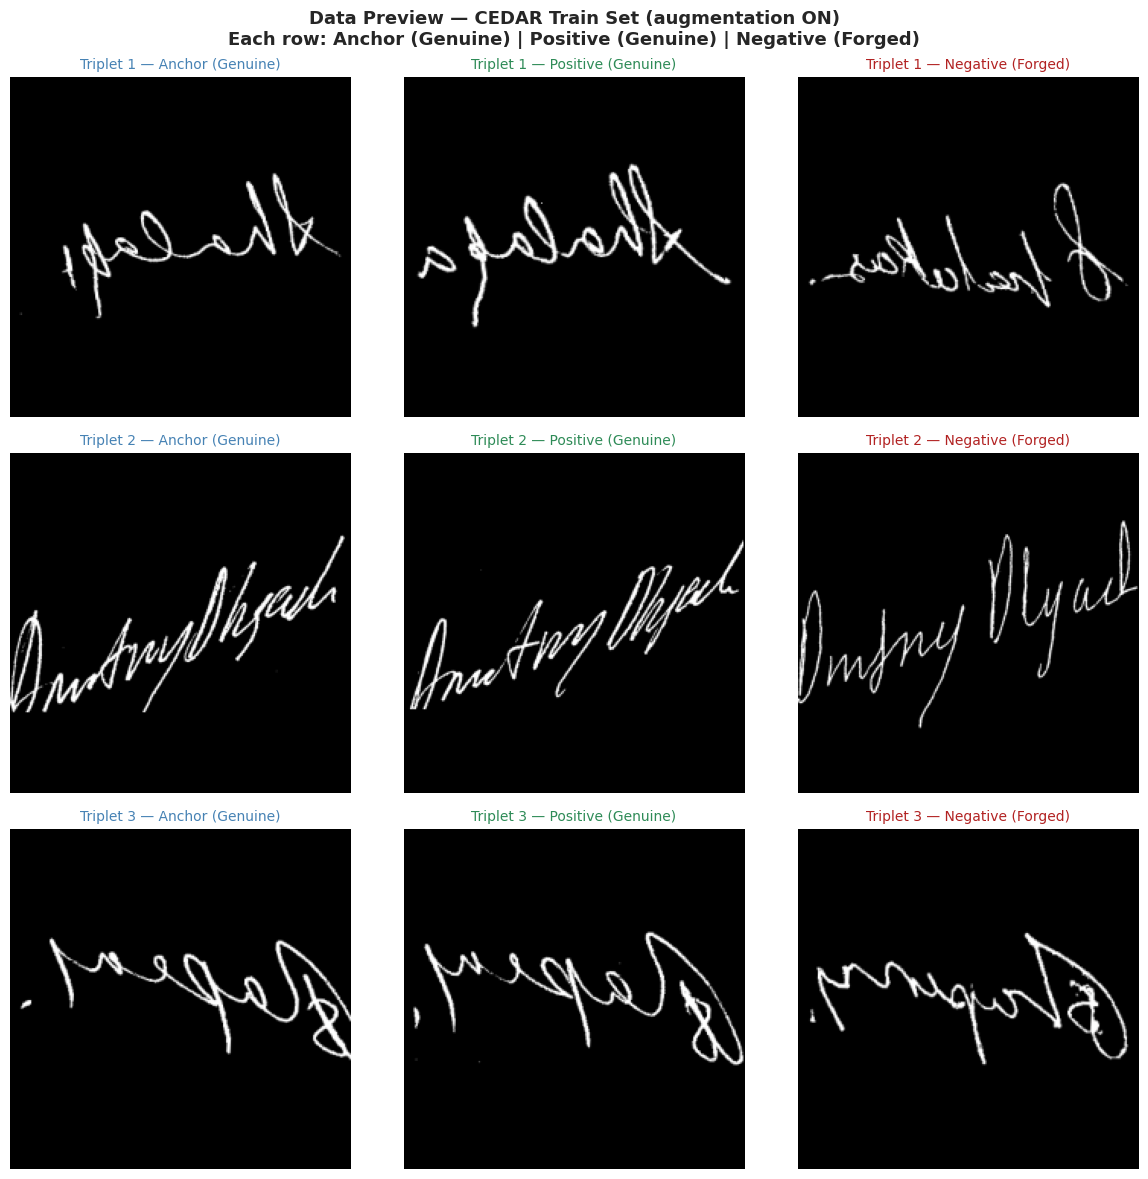

 > [Viz] Displayed 3 augmented triplets


In [5]:
def _unnorm(t):
    """Undo ImageNet normalisation for display. Returns H×W×C numpy in [0, 1]."""
    img  = t.cpu().numpy().transpose(1, 2, 0)          # C,H,W → H,W,C
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    return np.clip(std * img + mean, 0, 1)


# ── Preview: sample augmented triplets from first available split ─────────────
# Uses SplitTripletDataset with train_transform (augmentation ON) so the display
# shows exactly what Step 1 pretraining receives. Runs independently of the
# training loop — purely for pipeline verification before training starts.
_prev_data = None
for _r in SPLIT_RATIOS:
    _f = os.path.join(SPLIT_DIR, f"{DATASET}_split_{_r}.json")
    if os.path.exists(_f):
        with open(_f) as _fh:
            _prev_data = json.load(_fh)
        print(f" > [Viz] Preview using split '{_r}'")
        break

if _prev_data is None:
    print(" > [Viz] No split file found — run prepare_split_ratios.py first")
else:
    _ds      = SplitTripletDataset(_prev_data['train'], input_shape=INPUT_SHAPE, val_transform=val_transform, training=True)
    _loader  = DataLoader(_ds, batch_size=4, shuffle=True, num_workers=0)
    _a, _p, _n, _ = next(iter(_loader))

    N = min(3, _a.size(0))   # show up to 3 triplets
    fig, axes = plt.subplots(N, 3, figsize=(12, 4 * N))
    fig.suptitle(
        f"Data Preview — {DATASET_NAME} Train Set (augmentation ON)\n"
        "Each row: Anchor (Genuine) | Positive (Genuine) | Negative (Forged)",
        fontsize=13, fontweight='bold')

    if N == 1:                           # ensure 2-D indexing works for N=1
        axes = axes[np.newaxis, :]

    for i in range(N):
        for j, (tensor, title, color) in enumerate(zip(
                [_a[i], _p[i], _n[i]],
                ["Anchor (Genuine)", "Positive (Genuine)", "Negative (Forged)"],
                ['steelblue',        'seagreen',           'firebrick'])):
            axes[i, j].imshow(_unnorm(tensor))
            axes[i, j].set_title(f"Triplet {i+1} — {title}",
                                  fontsize=10, color=color)
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()
    print(f" > [Viz] Displayed {N} augmented triplets")


## Step 6 — Training Utilities

Contains all functions required for both training steps:

| Function | Role |
|---|---|
| `freeze_backbone` / `unfreeze_backbone` | Phase-transition helpers |
| `meta_train_epoch` | One episodic meta-training epoch |
| `meta_validate` | Episodic inference → `compute_metrics()` |
| `evaluate_model` | Thin wrapper: validate + optional plots |
| `run_pretraining` | Full Step 1 loop (two-phase, triplet loss) |
| `run_meta_training` | Full Step 2 loop (two-phase, differential LR) |

In [6]:
# ── Backbone freeze / unfreeze ────────────────────────────────────────────────
def freeze_backbone(fe):
    """
    Freeze DenseNet backbone parameters.
    CBAM modules and regularized_dense_block remain trainable.
    Uses fe.get_backbone_params() so behaviour stays consistent if the
    architecture changes.
    """
    for p in fe.get_backbone_params():
        p.requires_grad = False

def unfreeze_backbone(fe):
    """Unfreeze all feature extractor parameters."""
    for p in fe.parameters():
        p.requires_grad = True


# ── One epoch of episodic meta-training ──────────────────────────────────────
def meta_train_epoch(fe, mg, loader, optimizer, criterion, device):
    """
    One episodic meta-training epoch.

    For each episode in the batch:
        1. Extract support embedding (K genuine reference signatures → fe)
        2. Expand support to pair with each of the N_Q queries
        3. Extract query embeddings (genuine + forged → fe)
        4. Concatenate [support_feat ‖ query_feat] → MetricGenerator → logit
        5. BCEWithLogitsLoss against genuine/forged labels

    Returns:
        (avg_loss, accuracy) over all query-support pairs in the epoch.
    """
    fe.train();  mg.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch in tqdm(loader, desc="Meta-Train", leave=False):
        sup_imgs = batch['support_images'].squeeze(1).to(device)  # [B, C, H, W]
        qry_imgs = batch['query_images'].to(device)               # [B, N_Q, C, H, W]
        labels   = batch['query_labels'].to(device)               # [B, N_Q]

        B, N_Q, C, H, W = qry_imgs.shape
        qry_flat = qry_imgs.view(B * N_Q, C, H, W)
        lbl_flat = labels.view(B * N_Q).unsqueeze(1)
        # Each support image is paired with every one of its N_Q queries
        sup_flat = sup_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)

        optimizer.zero_grad()
        scores = mg(torch.cat((fe(sup_flat), fe(qry_flat)), dim=1))
        loss   = criterion(scores, lbl_flat)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct      += ((torch.sigmoid(scores) > 0.5).float() == lbl_flat).sum().item()
        total        += lbl_flat.size(0)

    return running_loss / len(loader), correct / total


# ── Episodic validation / inference ──────────────────────────────────────────
def meta_validate(fe, mg, loader, device):
    """
    Run inference over all episodes without gradient computation.

    Collects P(genuine) = sigmoid(mg(...)) scores with label 1 = genuine.
    Score and label polarity are consistent — EER / AUC from compute_metrics()
    are correct as-is and directly comparable to the baseline's metrics.

    Returns:
        dict: compute_metrics() output (eer, auc, accuracy, precision, recall, f1, …)
    """
    fe.eval();  mg.eval()
    all_labels, all_scores = [], []

    with torch.no_grad():
        for batch in loader:
            sup_imgs = batch['support_images'].squeeze(1).to(device)
            qry_imgs = batch['query_images'].to(device)
            labels   = batch['query_labels'].to(device)

            B, N_Q, C, H, W = qry_imgs.shape
            qry_flat = qry_imgs.view(B * N_Q, C, H, W)
            lbl_flat = labels.view(B * N_Q).unsqueeze(1)
            sup_flat = sup_imgs.unsqueeze(1).expand(-1, N_Q, -1, -1, -1).reshape(B * N_Q, C, H, W)

            probs = torch.sigmoid(mg(torch.cat((fe(sup_flat), fe(qry_flat)), dim=1)))
            all_scores.extend(probs.cpu().numpy().flatten())
            all_labels.extend(lbl_flat.cpu().numpy().flatten())

    return compute_metrics(all_labels, all_scores)


def evaluate_model(fe, mg, loader, device, output_dir=None, silent=False):
    """Thin wrapper: runs meta_validate then optionally prints metrics and saves plots."""
    metrics = meta_validate(fe, mg, loader, device)

    if output_dir and not silent:
        print(f"\n{'='*10} FINAL TEST RESULTS {'='*10}")
        for k, fmt in [('eer',':.2%'),('auc',':.4f'),('threshold',':.4f'),
                       ('accuracy',':.2%'),('precision',':.2%'),
                       ('recall',':.2%'),('f1',':.2%')]:
            print(f"  {k.upper():<13}: {metrics.get(k, 0):{fmt[1:]}}")
        print("=" * 38)
        _plot_roc_curve(metrics, output_dir)
        _plot_score_distribution(metrics, output_dir)
        _plot_confusion_matrix(metrics, output_dir)
        _plot_det_curve(metrics, output_dir)
        _plot_far_frr(metrics, output_dir)

    return metrics


# ── Step 1: Pretraining ───────────────────────────────────────────────────────
def run_pretraining(train_user_dict, device, checkpoint_path,
                    epochs=30, phase1_epochs=8, lr=1e-4,
                    margin=1.0, batch_size=32):
    """
    Pretrain the DenseNet-121 + CBAM feature extractor with TripletLoss.

    Two-phase training:
        Phase 1 (frozen backbone, 0 → phase1_epochs-1):
            Only CBAM modules and regularized_dense_block train via Adam(lr).
            Allows CBAM to learn initial attention maps before the backbone
            is released from its ImageNet initialisation.
        Phase 2 (unfrozen, phase1_epochs → epochs-1):
            Full model fine-tuned via Adam(lr * 0.1) +
            ReduceLROnPlateau(factor=0.5, patience=5) on training loss.

    Saves feature_extractor.state_dict() of the best (lowest-loss) epoch.
    Triplets are regenerated at the end of every epoch to prevent memorisation
    of fixed pairings.

    Returns:
        str: Path to the saved checkpoint.
    """
    print(f"\n   {'─'*56}")
    print(f"   STEP 1 — PRETRAINING  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR: {lr}  |  Margin: {margin}  |  Batch: {batch_size}")
    print(f"   {'─'*56}")

    seed_everything(42)
    t0 = time.time()

    dataset   = SplitTripletDataset(train_user_dict, input_shape=INPUT_SHAPE, val_transform=val_transform, training=True)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    model     = tDCBAM(backbone_name='densenet121',
                       output_dim=FEATURE_DIM, pretrained=True).to(device)
    criterion = TripletLoss(margin=margin, mode='euclidean')

    # ── Phase 1: frozen backbone ──────────────────────────────────────────
    freeze_backbone(model.feature_extractor)
    n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in model.parameters())
    print(f"   Phase 1: {n_train:,} / {n_total:,} params trainable (backbone frozen)")

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = None
    best_loss = float('inf')

    for epoch in range(epochs):
        # ── Phase transition ──────────────────────────────────────────────
        if epoch == phase1_epochs:
            unfreeze_backbone(model.feature_extractor)
            n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
            print(f"   Phase 2: {n_train:,} params trainable (backbone unfrozen)")
            optimizer = optim.Adam(model.parameters(), lr=lr * 0.1)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                            optimizer, mode='min', factor=0.5, patience=5)

        model.train()
        epoch_loss = 0.0
        for anchor, pos, neg, _ in tqdm(loader, desc=f"Pretrain E{epoch+1:02d}", leave=False):
            anchor, pos, neg = anchor.to(device), pos.to(device), neg.to(device)
            optimizer.zero_grad()
            loss = criterion(*model(anchor, pos, neg))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        phase    = 1 if epoch < phase1_epochs else 2
        print(f"   [P{phase}] Epoch {epoch+1:02d}/{epochs} | "
              f"Loss: {avg_loss:.4f} | "
              f"Active triplets: {criterion.last_fraction_active:.1%}")

        if scheduler is not None:
            scheduler.step(avg_loss)
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.feature_extractor.state_dict(), checkpoint_path)

        dataset._generate_triplets()   # reshuffle each epoch

    print(f"   Pretraining done | Best loss: {best_loss:.4f} | "
          f"Time: {time.time() - t0:.1f}s")
    return checkpoint_path


# ── Step 2: Meta-training ─────────────────────────────────────────────────────
def run_meta_training(train_user_dict, val_user_dict, test_user_dict,
                      pretrained_path, device, checkpoint_path,
                      epochs=70, phase1_epochs=20,
                      lr_phase1=1e-3, lr_backbone=1e-5, lr_head=2e-4,
                      weight_decay=1e-2, batch_size=16, output_dir=None):
    """
    Episodic meta-training of the full DenseNet + CBAM + MetricGenerator stack.

    Two-phase training:
        Phase 1 (frozen backbone, 0 → phase1_epochs-1):
            AdamW([head_params @ lr_phase1, mg_params @ lr_phase1], wd=weight_decay)
            ReduceLROnPlateau(factor=0.5, patience=5) on val EER.
        Phase 2 (unfrozen, phase1_epochs → epochs-1):
            Differential LR via AdamW:
                backbone params  → lr_backbone  (conservative fine-tune)
                head / CBAM / mg → lr_head      (faster adaptation)
            ReduceLROnPlateau(factor=0.5, patience=5) on val EER.

    Model selection: checkpoint saved on every val EER improvement.
    Final evaluation: best checkpoint reloaded; test set NEVER seen during training.

    Returns:
        dict: Final test metrics from compute_metrics().
    """
    print(f"\n   {'─'*56}")
    print(f"   STEP 2 — META-TRAINING  |  {epochs} epochs  "
          f"(P1 frozen: {phase1_epochs})")
    print(f"   LR P1: {lr_phase1}  |  backbone: {lr_backbone}  |  head: {lr_head}")
    print(f"   WD: {weight_decay}  |  Batch: {batch_size}")
    print(f"   {'─'*56}")

    t0 = time.time()

    # ── Datasets & loaders ────────────────────────────────────────────────
    train_set = SplitEpisodicDataset(train_user_dict, K_SHOT,
                                      N_QUERY_GENUINE, N_QUERY_FORGERY, augment=True)
    val_set   = SplitEpisodicDataset(val_user_dict,   K_SHOT,
                                      N_QUERY_GENUINE, N_QUERY_FORGERY, augment=False)
    test_set  = SplitEpisodicDataset(test_user_dict,  K_SHOT,
                                      N_QUERY_GENUINE, N_QUERY_FORGERY,
                                      augment=False, exhaustive_eval=True)

    # drop_last=True on train/val — prevents shape mismatch in episodic reshaping.
    # drop_last=False on test — ensures every sample is evaluated.
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                               num_workers=NUM_WORKERS, drop_last=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False,
                               num_workers=NUM_WORKERS, drop_last=False)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False,
                               num_workers=NUM_WORKERS, drop_last=False)

    # ── Model init + load pretrained backbone ─────────────────────────────
    fe = DenseNetFeatureExtractor('densenet121', output_dim=FEATURE_DIM).to(device)
    mg = MetricGenerator(embedding_dim=EMBEDDING_DIM).to(device)

    # Step 1 saves feature_extractor.state_dict() directly — no key prefix to strip.
    if os.path.exists(pretrained_path):
        state = torch.load(pretrained_path, map_location=device, weights_only=False)
        try:
            fe.load_state_dict(state, strict=True)
            print("   Pretrained weights loaded (strict)")
        except RuntimeError as e:
            fe.load_state_dict(state, strict=False)
            print(f"   Pretrained weights loaded (partial — check keys): {e}")
    else:
        print(f"   WARNING: {pretrained_path} not found — ImageNet init only")

    criterion = nn.BCEWithLogitsLoss()
    best_eer, best_acc, best_metrics = 1.0, 0.0, {}

    def _save_ckpt(val_m):
        torch.save({
            'feature_extractor': fe.state_dict(),
            'metric_generator':  mg.state_dict(),
            'metrics': {k: float(v) for k, v in val_m.items()
                        if isinstance(v, (int, float, np.floating))}
        }, checkpoint_path)

    # ── Phase 1: frozen backbone ──────────────────────────────────────────
    freeze_backbone(fe)
    n_train = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 1: {n_train:,} fe params trainable (backbone frozen)")

    optimizer = optim.AdamW([{'params': fe.get_head_params(), 'lr': lr_phase1},
                              {'params': mg.parameters(),      'lr': lr_phase1}],
                             weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.8, patience=8)

    for epoch in range(phase1_epochs):
        tr_loss, tr_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_m           = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc = val_m['eer'], val_m['accuracy']
        print(f"   [P1] Epoch {epoch+1:02d}/{phase1_epochs} | "
              f"Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_m
            _save_ckpt(val_m)
            print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")

    # ── Phase 2: unfrozen backbone with differential LR ───────────────────
    unfreeze_backbone(fe)
    n_train = sum(p.numel() for p in fe.parameters() if p.requires_grad)
    print(f"   Phase 2: {n_train:,} fe params trainable (all unfrozen)")

    optimizer = optim.AdamW([{'params': fe.get_backbone_params(), 'lr': lr_backbone},
                              {'params': fe.get_head_params(),     'lr': lr_head},
                              {'params': mg.parameters(),          'lr': lr_head}],
                             weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.8, patience=8)

    for epoch in range(epochs - phase1_epochs):
        tr_loss, tr_acc = meta_train_epoch(fe, mg, train_loader, optimizer, criterion, device)
        val_m           = meta_validate(fe, mg, val_loader, device)
        val_eer, val_acc = val_m['eer'], val_m['accuracy']
        g_ep = phase1_epochs + epoch + 1
        print(f"   [P2] Epoch {epoch+1:02d}/{epochs - phase1_epochs} (G:{g_ep:02d}) | "
              f"Loss: {tr_loss:.4f} | Acc: {tr_acc:.2%} | "
              f"Val EER: {val_eer:.2%} | Val Acc: {val_acc:.2%}")
        scheduler.step(val_eer)
        if val_eer < best_eer or (val_eer == best_eer and val_acc > best_acc):
            best_eer, best_acc, best_metrics = val_eer, val_acc, val_m
            _save_ckpt(val_m)
            print(f"   >>> Checkpoint saved  (Val EER: {val_eer:.2%})")

    # ── Final evaluation: reload best checkpoint, evaluate on test set ────
    # Test set was never seen during training — reloading ensures we report
    # results from the best validation checkpoint, not the last epoch.
    if output_dir and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        if isinstance(ckpt, dict) and 'feature_extractor' in ckpt:
            fe.load_state_dict(ckpt['feature_extractor'], strict=True)
            mg.load_state_dict(ckpt['metric_generator'],  strict=True)
            print("   Best checkpoint reloaded for final test evaluation")
        best_metrics = evaluate_model(fe, mg, test_loader, device,
                                       output_dir=output_dir, silent=False)

    print(f"   Meta-training done | Best Val EER: {best_eer:.2%} | "
          f"Time: {time.time() - t0:.1f}s")
    return best_metrics

print(" > [Utils] All training functions defined")


 > [Utils] All training functions defined


## Step 7 — Run All Splits

In [7]:
all_results = {}
timing_log  = {}

for ratio in SPLIT_RATIOS:
    split_file = os.path.join(SPLIT_DIR, f"{DATASET}_split_{ratio}.json")
    tr_p, va_p, te_p = ratio.split('_')
    split_label    = f"{tr_p}:{va_p}:{te_p}"
    split_eval_dir = os.path.join(EVAL_DIR, f"{NOTEBOOK_NAME}_{tr_p}-{va_p}-{te_p}")
    exp_dir        = os.path.join(CHECKPOINT_DIR, f"{DATASET}_{ratio}")
    os.makedirs(split_eval_dir, exist_ok=True)
    os.makedirs(exp_dir,        exist_ok=True)

    print(f"\n{'='*70}")
    print(f"  {DATASET_NAME}  —  {split_label}  Split")
    print(f"{'='*70}")

    if not os.path.exists(split_file):
        print(f"  SKIPPED: split file not found ({split_file})"); continue

    with open(split_file) as f:
        split_data = json.load(f)
    train_dict, val_dict, test_dict = (split_data['train'],
                                       split_data['val'],
                                       split_data['test'])
    print(f"  Writers — Train: {len(train_dict)} | Val: {len(val_dict)} | Test: {len(test_dict)}")

    # ── Step 1: Pretrain feature extractor ────────────────────────────────
    seed_everything(42)
    pretrain_path = os.path.join(exp_dir, "pretrained_backbone.pth")
    t0_pre = time.time()
    run_pretraining(train_dict, device=DEVICE, checkpoint_path=pretrain_path,
                    epochs=PRETRAIN_EPOCHS, phase1_epochs=PRETRAIN_PHASE1_EPOCHS,
                    lr=PRETRAIN_LR, margin=PRETRAIN_MARGIN,
                    batch_size=PRETRAIN_BATCH_SIZE)
    t_pre = time.time() - t0_pre

    # ── Step 2: Meta-train MetricGenerator ───────────────────────────────
    seed_everything(42)
    meta_ckpt = os.path.join(exp_dir, "best_meta_model.pth")
    t0_meta   = time.time()
    best_metrics = run_meta_training(
        train_dict, val_dict, test_dict,
        pretrained_path=pretrain_path, device=DEVICE,
        checkpoint_path=meta_ckpt,
        epochs=META_EPOCHS, phase1_epochs=META_PHASE1_EPOCHS,
        lr_phase1=META_LR_PHASE1, lr_backbone=META_LR_BACKBONE,
        lr_head=META_LR_HEAD, weight_decay=META_WEIGHT_DECAY,
        batch_size=META_BATCH_SIZE, output_dir=split_eval_dir)
    t_meta = time.time() - t0_meta

    # ── Record ────────────────────────────────────────────────────────────
    key = f"{DATASET_NAME} ({split_label})"
    all_results[key] = {
        'dataset':     DATASET_NAME,     'split':      split_label,
        'train_users': len(train_dict),  'val_users':  len(val_dict),
        'test_users':  len(test_dict),
        'eer':       float(best_metrics['eer']),
        'accuracy':  float(best_metrics['accuracy']),
        'auc':       float(best_metrics['auc']),
        'precision': float(best_metrics.get('precision', 0)),
        'recall':    float(best_metrics.get('recall',    0)),
        'f1':        float(best_metrics.get('f1',        0)),
    }
    timing_log[key] = {'pretrain_s': round(t_pre,  1),
                        'meta_s':    round(t_meta, 1),
                        'total_s':   round(t_pre + t_meta, 1)}

    print(f"  RESULT [{split_label}]: EER={best_metrics['eer']:.2%} | "
          f"Acc={best_metrics['accuracy']:.2%} | AUC={best_metrics['auc']:.4f} | "
          f"F1={best_metrics.get('f1',0):.4f} | Time={t_pre+t_meta:.1f}s")

print(f"\n{'='*70}\nALL EXPERIMENTS COMPLETE\n{'='*70}")



  CEDAR  —  70:15:15  Split
  Writers — Train: 38 | Val: 8 | Test: 9
 > [Seed] 42

   ────────────────────────────────────────────────────────
   STEP 1 — PRETRAINING  |  30 epochs  (P1 frozen: 8)
   LR: 0.0001  |  Margin: 1.0  |  Batch: 32
   ────────────────────────────────────────────────────────
 > [Seed] 42
   TripletDataset: 912 triplets | 38 users | triplet-level aug
   Phase 1: 1,658,248 / 8,612,104 params trainable (backbone frozen)


Pretrain E01:   0%|          | 0/28 [00:00<?, ?it/s]

   [P1] Epoch 01/30 | Loss: 1.4201 | Active triplets: 28.1%


Pretrain E02:   0%|          | 0/28 [00:00<?, ?it/s]

   [P1] Epoch 02/30 | Loss: 1.4635 | Active triplets: 34.4%


...

   [P2] Epoch 48/50 (G:68) | Loss: 0.1097 | Acc: 96.88% | Val EER: 25.00% | Val Acc: 75.00%


Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 49/50 (G:69) | Loss: 0.2060 | Acc: 92.19% | Val EER: 25.00% | Val Acc: 68.75%


Meta-Train:   0%|          | 0/2 [00:00<?, ?it/s]

   [P2] Epoch 50/50 (G:70) | Loss: 0.1994 | Acc: 95.31% | Val EER: 37.50% | Val Acc: 62.50%
   Best checkpoint reloaded for final test evaluation

========== FINAL TEST RESULTS ==========
  EER          : 13.43%
  AUC          : 0.9341
  THRESHOLD    : 0.4615
  ACCURACY     : 86.52%
  PRECISION    : 86.06%
  RECALL       : 86.47%
  F1           : 86.27%
 > Saved ROC Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/roc_curve.png
 > Saved Distribution Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/score_distribution.png
 > Saved Confusion Matrix to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/confusion_matrix.png
 > Saved DET Curve to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar_70-15-15/det_curve.png
 > Saved FAR/FRR Plot to: /home/lawrence/workspace/thesis/thesis/model_evals/proposed_cedar/proposed_cedar

## Step 8 — Summary Table

In [8]:
W = 92
print(f"\n{'='*W}")
print(f"{'PROPOSED MODEL  —  ' + DATASET_NAME:^{W}}")
print(f"{'='*W}")
print(f"{'Split':<12} {'Train':>6} {'Val':>6} {'Test':>6}  "
      f"{'EER':>8} {'Accuracy':>9} {'AUC':>8} {'F1':>8}  "
      f"{'Pre(s)':>8} {'Meta(s)':>8} {'Total(s)':>9}")
print(f"{'-'*W}")
for key, res in all_results.items():
    t = timing_log.get(key, {})
    print(f"{res['split']:<12} {res['train_users']:>6} {res['val_users']:>6} "
          f"{res['test_users']:>6}  {res['eer']:>8.4f} {res['accuracy']:>9.4f} "
          f"{res['auc']:>8.4f} {res['f1']:>8.4f}  "
          f"{str(t.get('pretrain_s','—')):>8} {str(t.get('meta_s','—')):>8} "
          f"{str(t.get('total_s','—')):>9}")
print(f"{'='*W}")

results_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_results.json')
with open(results_path, 'w') as f:
    json.dump({'results': all_results, 'timing': timing_log}, f, indent=2)
print(f"\n > Results saved → {results_path}")



                                  PROPOSED MODEL  —  CEDAR                                  
Split         Train    Val   Test       EER  Accuracy      AUC       F1    Pre(s)  Meta(s)  Total(s)
--------------------------------------------------------------------------------------------
70:15:15         38      8      9    0.1343    0.8652   0.9341   0.8627     177.2     90.1     267.2

 > Results saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_results.json


## Step 9 — Results Chart

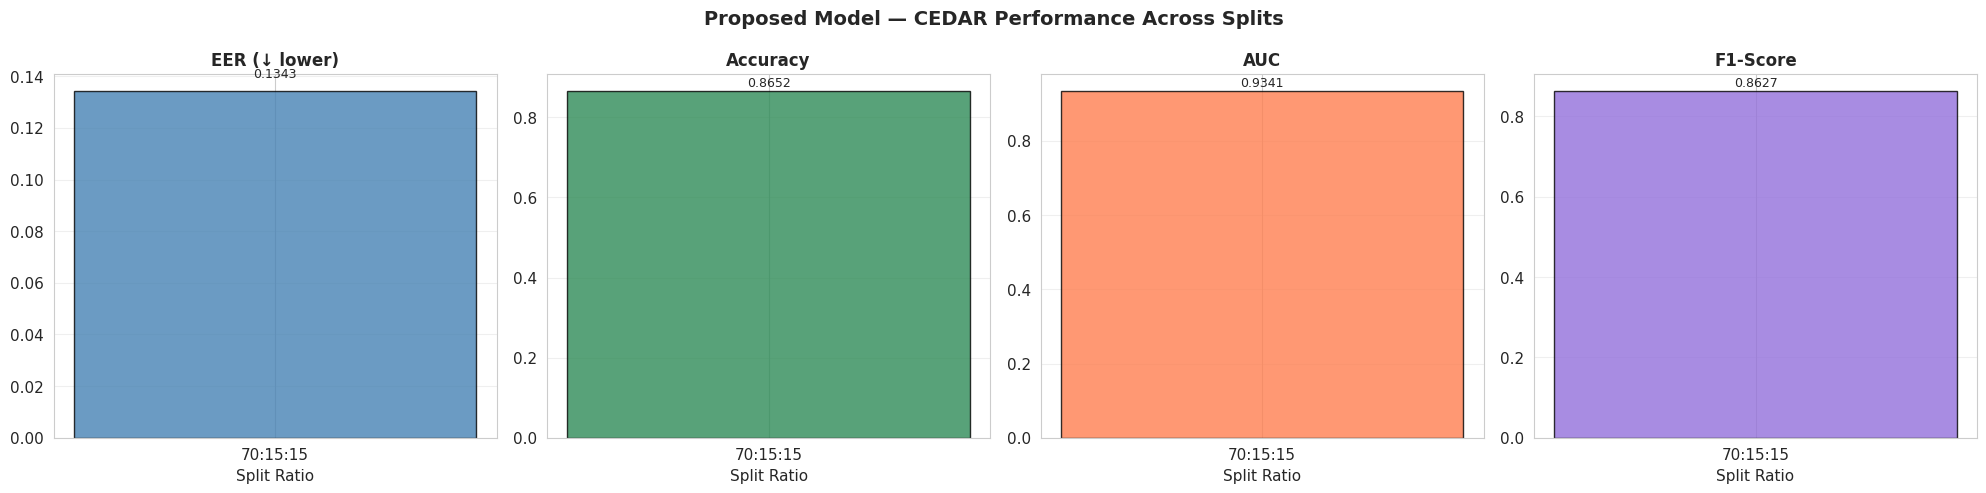

 > Plot saved → /home/lawrence/workspace/thesis/thesis/checkpoints/proposed_splits/proposed_cedar_comparison.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Proposed Model — {DATASET_NAME} Performance Across Splits',
             fontsize=14, fontweight='bold')

for ax, metric, title, color in zip(
        axes,
        ['eer',           'accuracy',  'auc',   'f1'],
        ['EER (↓ lower)', 'Accuracy',  'AUC',   'F1-Score'],
        ['steelblue',     'seagreen',  'coral', 'mediumpurple']):

    split_labels = [r.replace('_', ':') for r in SPLIT_RATIOS]
    values = [all_results.get(f"{DATASET_NAME} ({r.replace('_',':')})", {}).get(metric, 0)
              for r in SPLIT_RATIOS]

    bars = ax.bar(split_labels, values, color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Split Ratio', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = os.path.join(CHECKPOINT_DIR, f'proposed_{DATASET}_comparison.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f" > Plot saved → {plot_path}")
